In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### PART 1: Data Understanding (Exploratory Analysis)

In [2]:
df = pd.read_csv("Reviews.csv")

In [3]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
df.shape

(568454, 10)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 313.1 MB


In [6]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='str')

### Data cleaning

In [7]:
df.isnull().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [8]:
df['Summary'] = df['Summary'].fillna('')

In [9]:
df = df.drop(columns='ProfileName')

In [10]:
df['ProductId'].nunique() 

74258

In [11]:
df['UserId'].nunique() 

256059

In [12]:
df["Score"].value_counts().sort_index()

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

In [13]:
df = df.drop(columns = "Time")

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["HelpfullnessRatio"] = (df["HelpfulnessNumerator"]/df["HelpfulnessDenominator"])

In [16]:
df["HelpfullnessRatio"] = df["HelpfullnessRatio"].fillna(0)

In [17]:
df.head()

,Id,ProductId,UserId,HelpfulnessNumerator,HelpfulnessDenominator,Score,Summary,Text,HelpfullnessRatio
0,1,B001E4KFG0,A3SGXH7AUHU8GW,1,1,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,1.0
1,2,B00813GRG4,A1D87F6ZCVE5NK,0,0,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,0.0
2,3,B000LQOCH0,ABXLMWJIXXAIN,1,1,4,"""Delight"" says it all",This is a confection that has been around a fe...,1.0
3,4,B000UA0QIQ,A395BORC6FGVXV,3,3,2,Cough Medicine,If you are looking for the secret ingredient i...,1.0
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,0,0,5,Great taffy,Great taffy at a great price. There was a wid...,0.0


### Text preprocessing

In [18]:
import re
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [19]:
def clean(doc):
  #doc is a string of text
  # lets define a regex to match special characters and digits
    regex = "[^a-zA-Z.]"
    doc = re.sub(regex , " " ,doc)
    # convert to lower case
    doc = doc.lower()
    tokens = nltk.word_tokenize(doc)

    stop_words = stopwords.words("english")
    filtered_tokens = [token for token in tokens if token not in stop_words]

    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]
    return " ".join(lemmatized_tokens)

In [21]:
df['clean_summary'] = df['Summary'].apply(lambda x : clean(x))

In [24]:
df.head()

,Id,ProductId,UserId,HelpfulnessNumerator,HelpfulnessDenominator,Score,Summary,Text,HelpfullnessRatio,clean_text,clean_summary
0,1,B001E4KFG0,A3SGXH7AUHU8GW,1,1,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,1.0,bought several vitality canned dog food produc...,good quality dog food
1,2,B00813GRG4,A1D87F6ZCVE5NK,0,0,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,0.0,product arrived labeled jumbo salted peanut .....,advertised
2,3,B000LQOCH0,ABXLMWJIXXAIN,1,1,4,"""Delight"" says it all",This is a confection that has been around a fe...,1.0,confection around century . light pillowy citr...,delight say
3,4,B000UA0QIQ,A395BORC6FGVXV,3,3,2,Cough Medicine,If you are looking for the secret ingredient i...,1.0,looking secret ingredient robitussin believe f...,cough medicine
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,0,0,5,Great taffy,Great taffy at a great price. There was a wid...,0.0,great taffy great price . wide assortment yumm...,great taffy


In [50]:
df.to_csv("Cleaned_data")

In [74]:
df = pd.read_csv("Cleaned_data")

In [96]:
df.head(10)

,Unnamed: 0,Id,ProductId,UserId,HelpfulnessNumerator,HelpfulnessDenominator,Score,Summary,Text,HelpfullnessRatio,clean_text,clean_summary,Review
0,0,1,B001E4KFG0,A3SGXH7AUHU8GW,1,1,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,1.0,bought several vitality canned dog food produc...,good quality dog food,Positive
1,1,2,B00813GRG4,A1D87F6ZCVE5NK,0,0,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,0.0,product arrived labeled jumbo salted peanut .....,advertised,negative
2,2,3,B000LQOCH0,ABXLMWJIXXAIN,1,1,4,"""Delight"" says it all",This is a confection that has been around a fe...,1.0,confection around century . light pillowy citr...,delight say,Positive
3,3,4,B000UA0QIQ,A395BORC6FGVXV,3,3,2,Cough Medicine,If you are looking for the secret ingredient i...,1.0,looking secret ingredient robitussin believe f...,cough medicine,negative
4,4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,0,0,5,Great taffy,Great taffy at a great price. There was a wid...,0.0,great taffy great price . wide assortment yumm...,great taffy,Positive
5,5,6,B006K2ZZ7K,ADT0SRK1MGOEU,0,0,4,Nice Taffy,I got a wild hair for taffy and ordered this f...,0.0,got wild hair taffy ordered five pound bag . t...,nice taffy,Positive
6,6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,0,0,5,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...,0.0,saltwater taffy great flavor soft chewy . cand...,great good expensive brand,Positive
7,7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,0,0,5,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...,0.0,taffy good . soft chewy . flavor amazing . wou...,wonderful tasty taffy,Positive
8,8,9,B000E7L2R4,A1MZYO9TZK0BBI,1,1,5,Yay Barley,Right now I'm mostly just sprouting this so my...,1.0,right mostly sprouting cat eat grass . love . ...,yay barley,Positive
9,9,10,B00171APVA,A21BT40VZCCYT4,0,0,5,Healthy Dog Food,This is a very healthy dog food. Good for thei...,0.0,healthy dog food . good digestion . also good ...,healthy dog food,Positive


In [76]:
df.isnull().sum()

Unnamed: 0                   0
Id                           0
ProductId                    0
UserId                       0
HelpfulnessNumerator         0
HelpfulnessDenominator       0
Score                        0
Summary                     27
Text                         0
HelpfullnessRatio            0
clean_text                   0
clean_summary             1164
Review                       0
dtype: int64

In [78]:
df["clean_summary"].isnull().sum()

np.int64(1164)

In [79]:
df = df.dropna()

In [80]:
df.isnull().sum()

Unnamed: 0                0
Id                        0
ProductId                 0
UserId                    0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Score                     0
Summary                   0
Text                      0
HelpfullnessRatio         0
clean_text                0
clean_summary             0
Review                    0
dtype: int64

In [87]:
df_positive = df[df["Review"] == "Positive"]
df_negative = df[df["Review"] == "negative"]

In [95]:
df.to_csv("clean_data")

### EDA

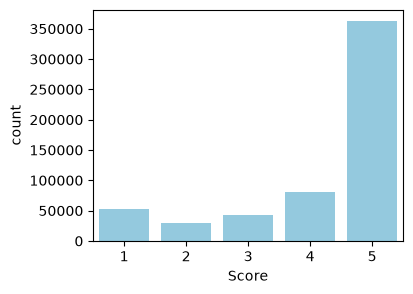

In [81]:
plt.figure(figsize=(4,3))
reviews = df["Score"].value_counts()
sns.barplot(reviews,color = 'skyblue')
plt.show()

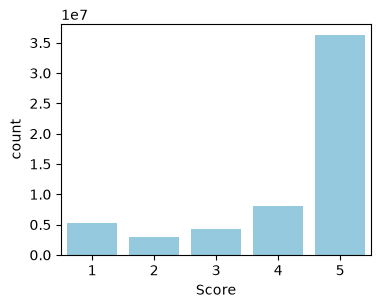

In [82]:
### Ratings percentage distribution
plt.figure(figsize=(4,3))
reviews = df["Score"].value_counts() * 100
sns.barplot(reviews,color = 'skyblue')
plt.show()

In [83]:
df["Review"] = df["Score"].apply(lambda x: "Positive" if x>3 else("negative" if x<3 else "Neutral"))

In [84]:
df["Review"].value_counts()

Review
Positive    443400
negative     81510
Neutral      42380
Name: count, dtype: int64

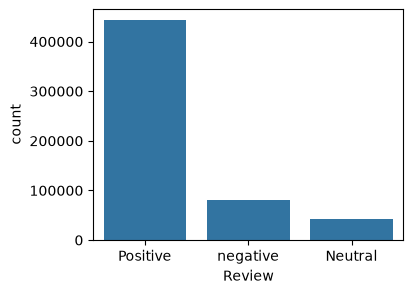

In [85]:
plt.figure(figsize=(4,3))
reviews = df["Review"].value_counts()
sns.barplot(reviews)
plt.show()

In [88]:
df_positive = df_positive.drop(columns = ["UserId",	"HelpfulnessNumerator",	"HelpfulnessDenominator","Text" , "Summary","Id"])
df_negative = df_negative.drop(columns = ["UserId",	"HelpfulnessNumerator",	"HelpfulnessDenominator","Text" , "Summary","Id"])

### Most frequent words in positive review

In [89]:
from collections import Counter
import re
# Function to clean text and extract words
def get_words(text):
  text = re.sub(r"[^a-zA-Z\s]","",text) #remove all special characters
  words = text.split()
  return words
# get all words from the dataset
all_words_pos = df_positive["clean_summary"].loc[:10000].apply(get_words).sum()
# count word frequencices
word_counts = Counter(all_words_pos)
# get the most common words
most_common_words = word_counts.most_common(10)
print(most_common_words)

[('great', 1266), ('good', 806), ('best', 602), ('love', 508), ('coffee', 487), ('delicious', 294), ('product', 289), ('taste', 268), ('tea', 232), ('dog', 230)]


### Most frequent words in Negative review

In [91]:
from collections import Counter
import re

def get_words(text):
    text = re.sub(r"[^a-zA-Z\s]" , "",text)
    words = text.split()
    return words
all_words_neg = df_negative["clean_summary"].loc[:10000].apply(get_words).sum()

word_counts = Counter(all_words_neg)

most_common_words = word_counts.most_common(10)
print(most_common_words)

[('taste', 106), ('good', 73), ('coffee', 65), ('like', 62), ('flavor', 54), ('product', 46), ('bad', 42), ('disappointed', 30), ('great', 30), ('awful', 28)]


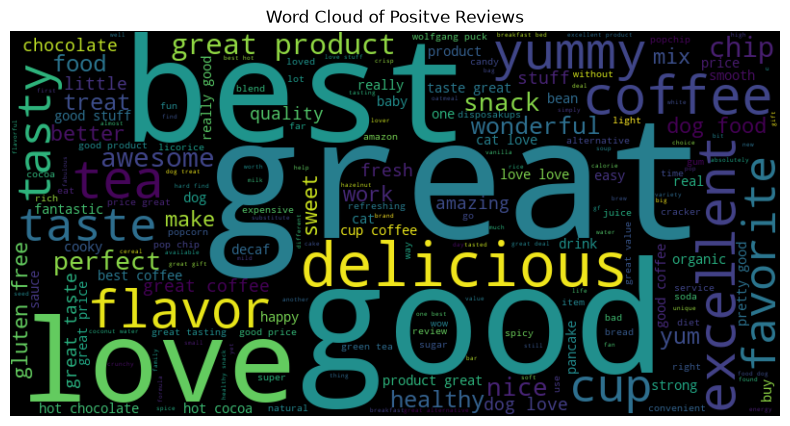

In [93]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800,
                      height = 400,
                      background_color = "black").generate(" ".join(all_words_pos))
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Positve Reviews")
plt.show()

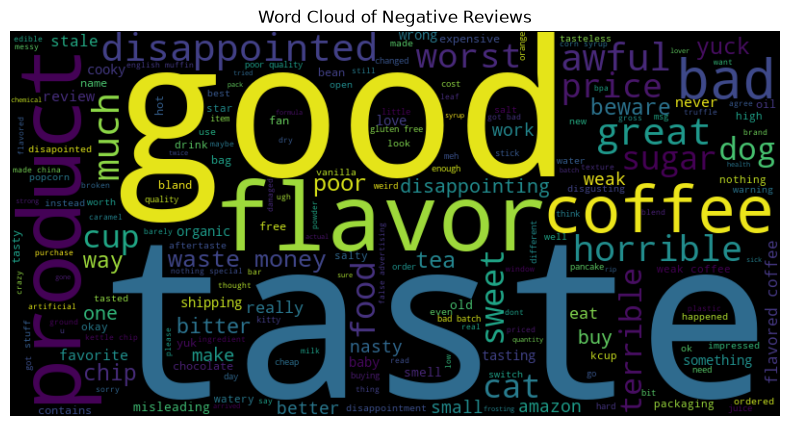

In [94]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800,
                      height = 400,
                      background_color = "black").generate(" ".join(all_words_neg))
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Negative Reviews")
plt.show()